In [1]:
!pip install numpy matplotlib pandas

Running QKD experiments...

Run 1
QBER: 0.0738
Key Length: 4970
Sample Secret Key: e5b65f322e69e8a7d3e89677ad2077eaf4c15ea0
-------------------------------
Run 2
QBER: 0.0696
Key Length: 5075
Sample Secret Key: 0faff74328d4cdbf5a74b58e75763ab52a48a994
-------------------------------
Run 3
QBER: 0.0741
Key Length: 5008
Sample Secret Key: d1251f96d5ac9c2f6a35299443def64859ade6d5
-------------------------------
Run 4
QBER: 0.0734
Key Length: 5000
Sample Secret Key: 84f940bf497c8dec01e6be19548863871805811b
-------------------------------
Run 5
QBER: 0.0742
Key Length: 5001
Sample Secret Key: b1b243af995d39129d24e590d489046549d36a0c
-------------------------------
Run 6
QBER: 0.0704
Key Length: 4957
Sample Secret Key: 98653f4cb52b5684e35e07a3d5bf63469cace440
-------------------------------
Run 7
QBER: 0.0761
Key Length: 4993
Sample Secret Key: 711fca50d3e51cb34f9ce7a9528d5ad42088aa03
-------------------------------
Run 8
QBER: 0.0687
Key Length: 4934
Sample Secret Key: 9f5cf6f905a1f3daa8dba

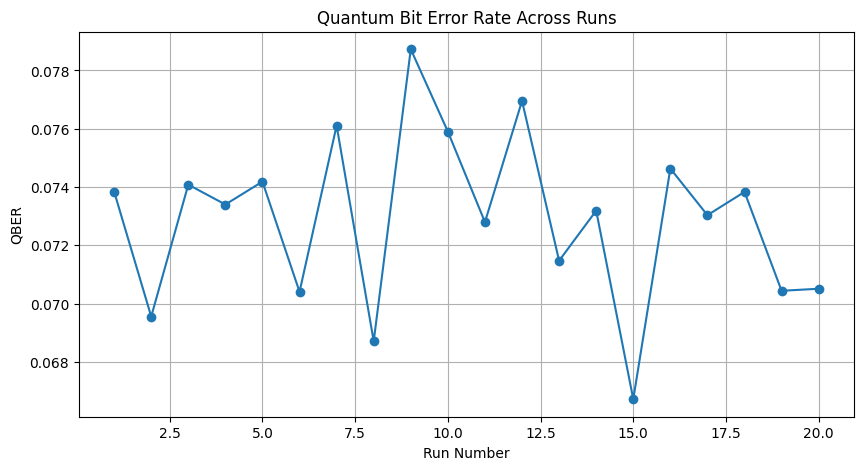

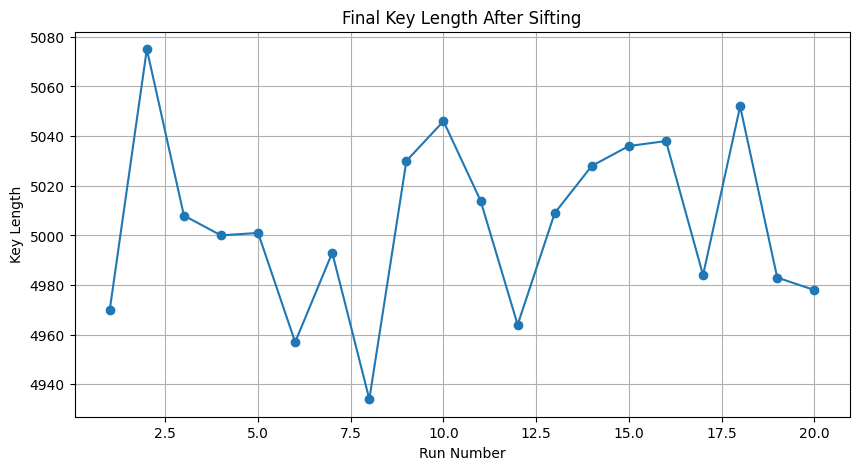

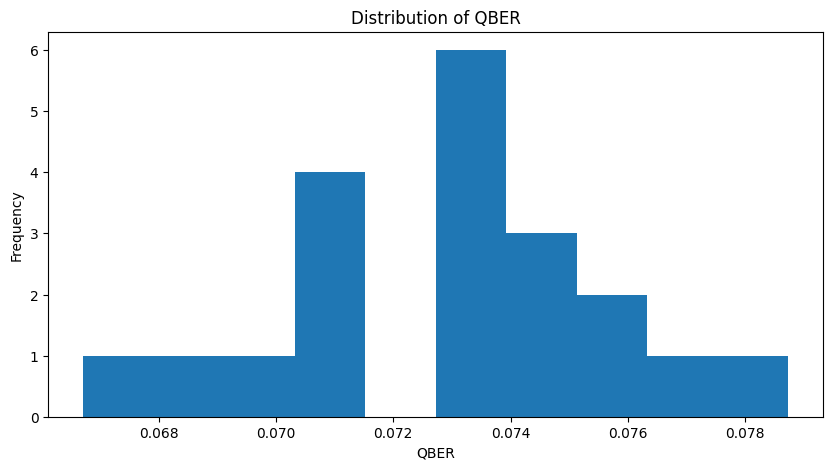


QKD Simulation Completed Successfully


In [4]:
# ===============================================
# QUANTUM KEY DISTRIBUTION (BB84) SIMULATION
# Industry-style Python project
# Works in Google Colab / Jupyter Notebook
# ===============================================

# ----------- IMPORT LIBRARIES ------------------

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import hashlib
import random

# Ensure plots appear in notebooks
%matplotlib inline

# ----------- GLOBAL CONFIGURATION ---------------

# Total photons/bits sent
NUM_BITS = 10000

# Whether Eve is present
EVE_PRESENT = True

# Probability that Eve intercepts a photon
EVE_INTERCEPT_PROB = 0.3

# Number of experiment runs
NUM_EXPERIMENTS = 20

# Fix random seed for reproducibility
np.random.seed(42)


# ===============================================
# STEP 1: RANDOM BIT GENERATION
# ===============================================

def generate_random_bits(n):
    """
    Alice generates random classical bits
    representing quantum states.
    """
    return np.random.randint(2, size=n)


# ===============================================
# STEP 2: RANDOM BASIS GENERATION
# ===============================================

def generate_random_bases(n):
    """
    Generate random measurement bases.
    0 = Rectilinear basis (+)
    1 = Diagonal basis (x)
    """
    return np.random.randint(2, size=n)


# ===============================================
# STEP 3: QUANTUM CHANNEL SIMULATION
# ===============================================

def quantum_channel(alice_bits, alice_bases, bob_bases):
    """
    Simulate Bob measuring photons.

    If Bob uses the same basis as Alice,
    he measures the correct bit.

    Otherwise the result is random.
    """

    n = len(alice_bits)
    bob_results = []

    for i in range(n):

        if alice_bases[i] == bob_bases[i]:
            bob_results.append(alice_bits[i])
        else:
            bob_results.append(np.random.randint(2))

    return np.array(bob_results)


# ===============================================
# STEP 4: EAVESDROPPER (EVE) ATTACK
# ===============================================

def eve_intercept(alice_bits, alice_bases):
    """
    Simulate intercept-resend attack.

    Eve randomly measures photons and resends them.
    """

    n = len(alice_bits)

    eve_bases = generate_random_bases(n)
    eve_results = []

    for i in range(n):

        if random.random() < EVE_INTERCEPT_PROB:

            if eve_bases[i] == alice_bases[i]:
                eve_results.append(alice_bits[i])
            else:
                eve_results.append(np.random.randint(2))

        else:
            eve_results.append(None)

    return eve_bases, eve_results


# ===============================================
# STEP 5: KEY SIFTING
# ===============================================

def sift_keys(alice_bits, alice_bases, bob_bits, bob_bases):
    """
    Alice and Bob keep only bits where
    they used the same measurement basis.
    """

    mask = alice_bases == bob_bases

    alice_key = alice_bits[mask]
    bob_key = bob_bits[mask]

    return alice_key, bob_key


# ===============================================
# STEP 6: QBER CALCULATION
# ===============================================

def compute_qber(alice_key, bob_key):
    """
    Compute Quantum Bit Error Rate (QBER).
    """

    errors = np.sum(alice_key != bob_key)

    return errors / len(alice_key)


# ===============================================
# STEP 7: ERROR CORRECTION (SIMPLIFIED)
# ===============================================

def error_correction(alice_key, bob_key):
    """
    Basic error correction step.

    Bob corrects bits that differ from Alice.
    """

    corrected = bob_key.copy()

    for i in range(len(alice_key)):

        if alice_key[i] != bob_key[i]:
            corrected[i] = alice_key[i]

    return corrected


# ===============================================
# STEP 8: PRIVACY AMPLIFICATION
# ===============================================

def privacy_amplification(key):
    """
    Compress key using SHA256 hashing.
    """

    key_string = ''.join(map(str, key))

    hashed_key = hashlib.sha256(key_string.encode()).hexdigest()

    return hashed_key


# ===============================================
# MAIN QKD PROTOCOL EXECUTION
# ===============================================

def run_qkd():

    # Alice generates bits and bases
    alice_bits = generate_random_bits(NUM_BITS)
    alice_bases = generate_random_bases(NUM_BITS)

    # Eve attack simulation
    if EVE_PRESENT:

        eve_bases, eve_results = eve_intercept(alice_bits, alice_bases)

        transmitted_bits = []

        for i in range(NUM_BITS):

            if eve_results[i] is None:
                transmitted_bits.append(alice_bits[i])
            else:
                transmitted_bits.append(eve_results[i])

        transmitted_bits = np.array(transmitted_bits)

    else:
        transmitted_bits = alice_bits

    # Bob chooses bases
    bob_bases = generate_random_bases(NUM_BITS)

    # Bob measures photons
    bob_results = quantum_channel(transmitted_bits, alice_bases, bob_bases)

    # Key sifting
    alice_key, bob_key = sift_keys(alice_bits, alice_bases, bob_results, bob_bases)

    # QBER calculation
    qber = compute_qber(alice_key, bob_key)

    # Error correction
    corrected_key = error_correction(alice_key, bob_key)

    # Privacy amplification
    final_key = privacy_amplification(corrected_key)

    return qber, len(alice_key), final_key


# ===============================================
# MULTIPLE EXPERIMENTS
# ===============================================

def experiment():

    qbers = []
    key_lengths = []

    print("Running QKD experiments...\n")

    for run in range(NUM_EXPERIMENTS):

        qber, key_len, final_key = run_qkd()

        qbers.append(qber)
        key_lengths.append(key_len)

        print(f"Run {run+1}")
        print("QBER:", round(qber,4))
        print("Key Length:", key_len)
        print("Sample Secret Key:", final_key[:40])
        print("-------------------------------")

    df = pd.DataFrame({
        "Run": range(1, NUM_EXPERIMENTS+1),
        "QBER": qbers,
        "KeyLength": key_lengths
    })

    return df


# ===============================================
# VISUALIZATION
# ===============================================

def visualize(df):

    # Plot QBER
    plt.figure(figsize=(10,5))

    plt.plot(df["Run"], df["QBER"], marker='o')

    plt.title("Quantum Bit Error Rate Across Runs")
    plt.xlabel("Run Number")
    plt.ylabel("QBER")
    plt.grid(True)

    plt.show()


    # Plot Key Length
    plt.figure(figsize=(10,5))

    plt.plot(df["Run"], df["KeyLength"], marker='o')

    plt.title("Final Key Length After Sifting")
    plt.xlabel("Run Number")
    plt.ylabel("Key Length")
    plt.grid(True)

    plt.show()


    # QBER Distribution
    plt.figure(figsize=(10,5))

    plt.hist(df["QBER"], bins=10)

    plt.title("Distribution of QBER")
    plt.xlabel("QBER")
    plt.ylabel("Frequency")

    plt.show()


# ===============================================
# RUN PROJECT
# ===============================================

df = experiment()

print("\nExperiment Summary Table")
print(df)

visualize(df)

print("\nQKD Simulation Completed Successfully")